# Rastair built-in model evaluation

In [4]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(caret)
  library("ggVennDiagram")
})
params <- list(threads=6,
               test_chr="chr12",
               rastair2 = "target/release/rastair2",
               test_fasta = "Analysis/data/chr12.fasta.gz",
               test_bam = "Analysis/data/aaf06_chr12.bam")

## Load data

In [5]:
truth.set <- fread(cmd=paste0("bcftools query -r ", params$test_chr, " -f '%CHROM\\t%POS\\t%REF\\t%ALT[\\t%GT]\\n' -i 'TYPE=\"SNP\" & FILTER=\"PASS\"' Analysis/data/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz"), header=FALSE, stringsAsFactors = TRUE)
setnames(truth.set, c("chr", "pos", "ref", "alt", "genotype"))

# subset truth set to regions that could have been called at all - not fair to compare regions without coverage
setkey(truth.set, chr, pos, ref, alt)

Run rastair2 call and extract relevant info

In [6]:
predictions.r2 <- fread(cmd=paste(params$rastair2, "call --vcf - -@", params$threads, "--ml 0.75 -l", params$test_chr, "-r", params$test_fasta, params$test_bam, "| bcftools norm -m-any | bcftools query -i 'AD[1]>1 & ALT != \".\"' -f '%CHROM\\t%POS\\t%REF\\t%ALT\\t%FILTER\\t%CPG\\t%CPGnovo[\\t%DP\\t%ML]\\n'"), header=FALSE, stringsAsFactors=TRUE, na.strings = c(".", "", "NA", "NaN", "*", "<*>"))
setnames(predictions.r2, c("chr", "pos", "ref", "alt", "filter", "cpg", "dn_cpg", "depth", "score"))

In [7]:
predictions.r2[is.na(cpg), cpg := 0]
predictions.r2[is.na(dn_cpg), dn_cpg := 0]

## Compare overlap of calls

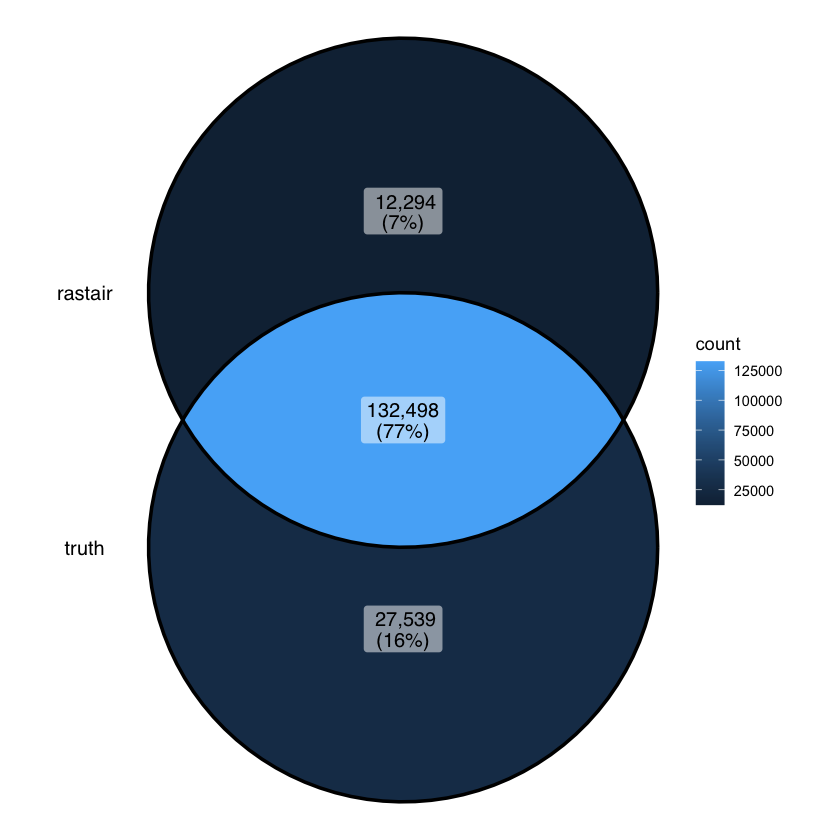

In [8]:
setkey(truth.set, chr, pos, ref, alt)
setkey(predictions.r2, chr, pos, ref, alt)

ggVennDiagram(list(truth=truth.set[chr==params$test_chr, paste0(chr, ":", pos, " ", ref, ">", alt)], rastair=predictions.r2[filter=="PASS", paste0(chr, ":", pos, " ", ref, ">", alt)]))

Something seems not quite right. The positive predictive value is in the right range (~87%), the false negative rate is way too high, even though most of those positions are covered. I used the same data for training, so I know that there should be only about 12k false negatives, not 84k.

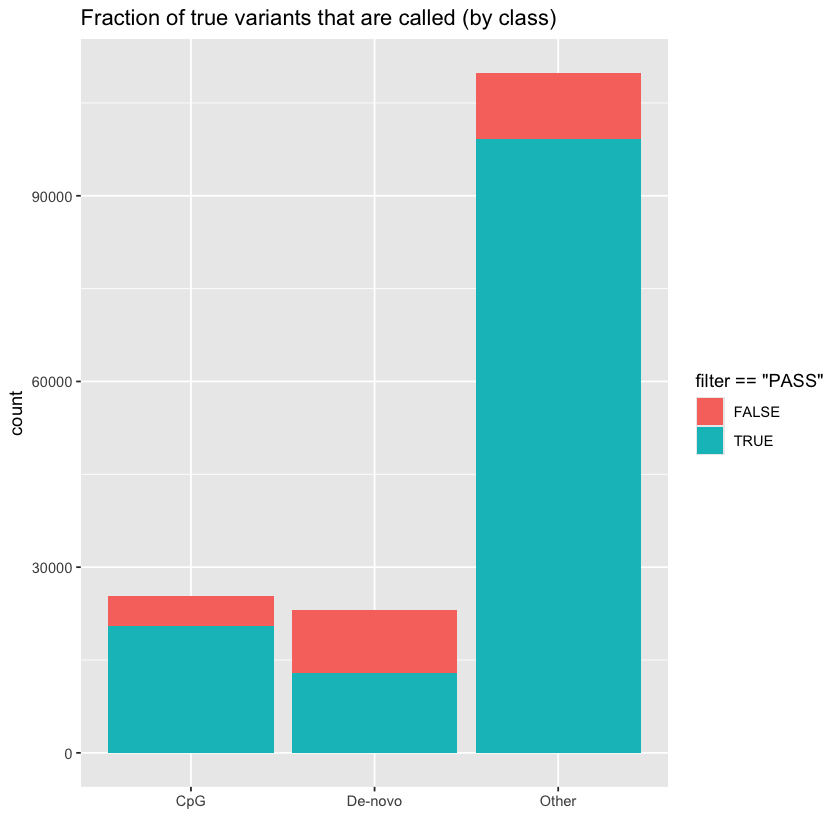

In [9]:
predictions.r2.true <- truth.set[, .(chr, pos, ref, alt, type="SNP")][predictions.r2]
predictions.r2.true[is.na(type), type := "REF"]
predictions.r2.true[, type := as.factor(type)]

ggplot(predictions.r2.true[type=="SNP"], aes(x=ifelse(cpg, "CpG", ifelse(dn_cpg, "De-novo", "Other")), fill=filter=="PASS")) + geom_bar() + xlab("") + ggtitle("Fraction of true variants that are called (by class)")